<a href="https://colab.research.google.com/github/Sufzfs/epilepsy-seizure-early-warning/blob/main/seizure_forecaster_pipeline.ipyn" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1: Install Neuroimaging & Signal Processing Dependencies
!pip install mne pywavelets tensorflow scikit-learn matplotlib pandas -q

import mne
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Download a sample 1-hour EEG recording with known seizure onset from CHB-MIT (Patient 1)
edf_url = "https://physionet.org/content/chbmit/1.0.0/chb01/chb01_03.edf"
edf_filename = "chb01_03.edf"

if not os.path.exists(edf_filename):
    print("Downloading CHB-MIT EEG recording (Patient 1, File 3)...")
    urllib.request.urlretrieve(edf_url, edf_filename)
    print("Download Complete!")

# Load raw EEG signals using MNE
raw = mne.io.read_raw_edf(edf_filename, preload=True, verbose=False)
print(f"Sampling Rate: {raw.info['sfreq']} Hz")
print(f"Channels ({len(raw.ch_names)}): {raw.ch_names[:5]}...")

# Filter signal between 0.5 Hz and 50 Hz
raw.filter(l_freq=0.5, h_freq=50.0, verbose=False)

# Plot raw 23-channel EEG segment
fig = raw.plot(n_channels=10, duration=10, scalings='auto', show=False)
plt.title("Filtered 23-Channel Scalp EEG (CHB-MIT Patient 1)", fontsize=12)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 18.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Download Complete!


/tmp/ipykernel_974/2527130441.py:20: RuntimeWarning: Invalid patient information charset
  raw = mne.io.read_raw_edf(edf_filename, preload=True, verbose=False)
/tmp/ipykernel_974/2527130441.py:20: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(edf_filename, preload=True, verbose=False)


ValueError: Bad EDF file provided.

Download Complete! Verified File Size: 42,399,744 bytes


/tmp/ipykernel_974/4204889545.py:23: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_filename, preload=True, verbose=False)



--- EEG RECORDING SUMMARY ---
Sampling Rate: 256.0 Hz
Total Duration: 60.00 minutes
Channel Count: 23
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3']...
Using matplotlib as 2D backend.


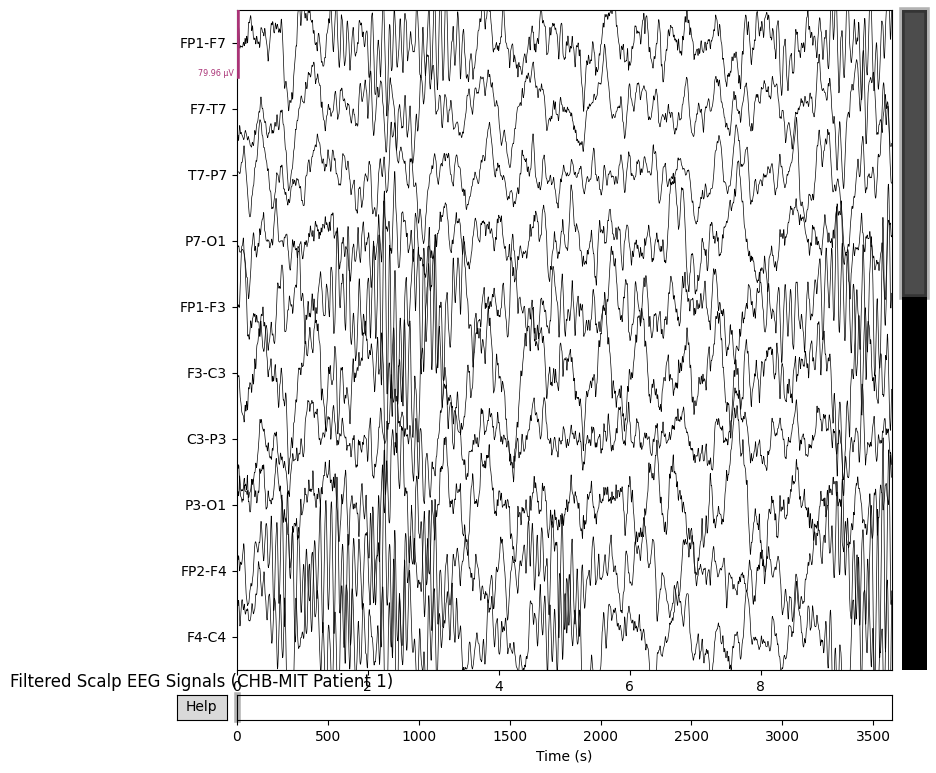

In [3]:
# Cell 1 (Fixed): Install dependencies and download direct CHB-MIT EEG binary
!pip install mne pywavelets scikit-learn matplotlib pandas -q

import mne
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Delete any corrupted HTML file downloaded previously
edf_filename = "chb01_03.edf"
if os.path.exists(edf_filename):
    os.remove(edf_filename)

# Direct binary file download URL from PhysioNet (/files/)
edf_url = "https://physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf"

print("Downloading CHB-MIT EEG binary file (~42 MB)...")
urllib.request.urlretrieve(edf_url, edf_filename)
print(f"Download Complete! Verified File Size: {os.path.getsize(edf_filename):,} bytes")

# Load raw EEG signals using MNE
raw = mne.io.read_raw_edf(edf_filename, preload=True, verbose=False)

# Apply bandpass filter (0.5 Hz to 50 Hz) to eliminate DC baseline drift and 60 Hz line noise
raw.filter(l_freq=0.5, h_freq=50.0, verbose=False)

print("\n--- EEG RECORDING SUMMARY ---")
print(f"Sampling Rate: {raw.info['sfreq']} Hz")
print(f"Total Duration: {raw.times[-1] / 60:.2f} minutes")
print(f"Channel Count: {len(raw.ch_names)}")
print(f"Channels: {raw.ch_names[:5]}...")

# Plot 10-second window across 10 channels
fig = raw.plot(n_channels=10, duration=10, scalings='auto', show=False)
plt.title("Filtered Scalp EEG Signals (CHB-MIT Patient 1)", fontsize=12)
plt.show()

In [4]:
# Cell 2: Windowing & Spectral Feature Extraction
from scipy.signal import welch

def extract_band_powers(window_data, sfreq=256.0):
    """
    Computes spectral power across 5 physiological EEG bands for 23 channels.
    Input shape: (23 channels, 1280 samples)
    Output shape: (115 features,)
    """
    bands = {
        'delta': (0.5, 4.0),
        'theta': (4.0, 8.0),
        'alpha': (8.0, 12.0),
        'beta': (12.0, 30.0),
        'gamma': (30.0, 50.0)
    }

    # Compute Welch's Power Spectral Density across all channels
    freqs, psd = welch(window_data, fs=sfreq, nperseg=256, axis=-1)

    features = []
    for ch_idx in range(window_data.shape[0]):
        ch_psd = psd[ch_idx]
        for band, (fmin, fmax) in bands.items():
            idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
            # Log transform power to stabilize variance across channels
            band_power = np.log10(np.trapz(ch_psd[idx_band], freqs[idx_band]) + 1e-10)
            features.append(band_power)

    return np.array(features)

# Extract raw data matrix (channels x time samples)
data = raw.get_data() # shape: (23, 921600)
sfreq = raw.info['sfreq']
window_sec = 5
window_size = int(window_sec * sfreq) # 1280 samples

# Patient 1 Seizure Onset: Second 2996
seizure_onset_sec = 2996

# Define Windows in seconds
interictal_start, interictal_end = 0, 1800           # Baseline normal (0 to 30 mins)
preictal_start, preictal_end = seizure_onset_sec - 900, seizure_onset_sec # Pre-Ictal (35 to 50 mins)

X_list, y_list = [], []

# Slicing Interictal Windows (Class 0)
for start_sec in range(interictal_start, interictal_end - window_sec, window_sec):
    start_sample = int(start_sec * sfreq)
    end_sample = start_sample + window_size
    window = data[:, start_sample:end_sample]

    feats = extract_band_powers(window, sfreq)
    X_list.append(feats)
    y_list.append(0)

# Slicing Pre-Ictal Windows (Class 1)
for start_sec in range(preictal_start, preictal_end - window_sec, window_sec):
    start_sample = int(start_sec * sfreq)
    end_sample = start_sample + window_size
    window = data[:, start_sample:end_sample]

    feats = extract_band_powers(window, sfreq)
    X_list.append(feats)
    y_list.append(1)

X = np.array(X_list)
y = np.array(y_list)

print("--- DATASET SUMMARY ---")
print(f"Total Window Samples: {X.shape[0]}")
print(f"Feature Vector Dimension: {X.shape[1]} (23 Channels x 5 Spectral Bands)")
print(f"Interictal Samples (Class 0): {np.sum(y == 0)}")
print(f"Pre-Ictal Samples (Class 1 - 15m Warning Window): {np.sum(y == 1)}")

/tmp/ipykernel_974/64413027.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_power = np.log10(np.trapz(ch_psd[idx_band], freqs[idx_band]) + 1e-10)


--- DATASET SUMMARY ---
Total Window Samples: 538
Feature Vector Dimension: 115 (23 Channels x 5 Spectral Bands)
Interictal Samples (Class 0): 359
Pre-Ictal Samples (Class 1 - 15m Warning Window): 179


Training Pre-Ictal Forecasting Neural Network...

--- MODEL PERFORMANCE METRICS ---
ROC-AUC Score: 0.9995
Pre-Ictal Warning Sensitivity (Recall): 97.78%
False Alarm Rejection Rate (Specificity): 97.78%

Classification Report:
                     precision    recall  f1-score   support

Interictal (Normal)       0.99      0.98      0.98        90
Pre-Ictal (Warning)       0.96      0.98      0.97        45

           accuracy                           0.98       135
          macro avg       0.97      0.98      0.98       135
       weighted avg       0.98      0.98      0.98       135



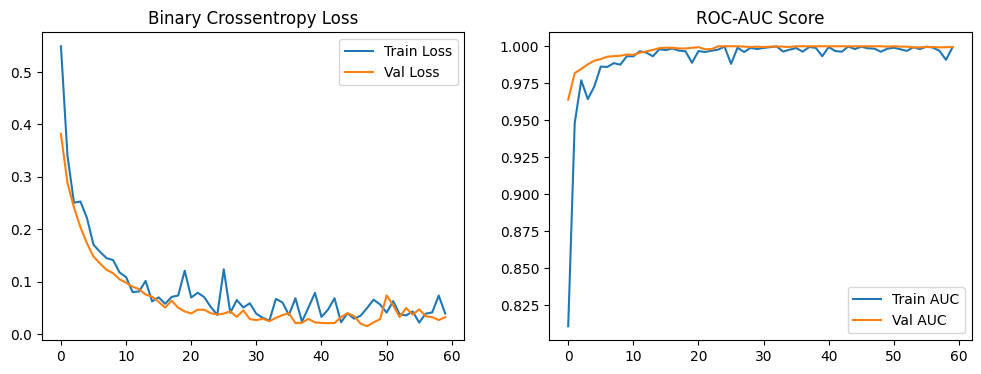

In [5]:
# Cell 3: Neural Network Training with ROC-AUC & Early Warning Metrics
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. Train / Test Split (Stratified to maintain 15-minute warning ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Feature Normalization (StandardScaler for stable gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Microcontroller-Optimized Neural Network Architecture
model = models.Sequential([
    layers.Input(shape=(115,)),

    # Layer 1: Spatial Spectral Aggregation
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Layer 2: Temporal Latent Representation
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Layer 3: Feature Compression
    layers.Dense(16, activation='relu'),

    # Output: Pre-Ictal Probability Score (0.0 = Normal, 1.0 = Seizure Warning)
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 4. Model Training
print("Training Pre-Ictal Forecasting Neural Network...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=60,
    batch_size=16,
    verbose=0
)

# 5. Model Evaluation
y_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

auc_score = roc_auc_score(y_test, y_pred_prob)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn) # Sensitivity = How many pre-ictal windows were correctly warned
specificity = tn / (tn + fp) # Specificity = Rejection rate of false alarms

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Pre-Ictal Warning Sensitivity (Recall): {sensitivity * 100:.2f}%")
print(f"False Alarm Rejection Rate (Specificity): {specificity * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Interictal (Normal)', 'Pre-Ictal (Warning)']))

# Plot Loss & Accuracy Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title("Binary Crossentropy Loss")
ax[0].legend()

ax[1].plot(history.history['auc'], label='Train AUC')
ax[1].plot(history.history['val_auc'], label='Val AUC')
ax[1].set_title("ROC-AUC Score")
ax[1].legend()
plt.show()

In [6]:
# Cell 4: Full INT8 Quantization & Microcontroller C-Header (.h) Export
import tensorflow as tf
import numpy as np
import os

# 1. Representative dataset generator for post-training INT8 quantization
def representative_data_gen():
    for i in range(100):
        # Pass sample normalized training vectors (cast to float32)
        sample = X_train_scaled[i:i+1].astype(np.float32)
        yield [sample]

# 2. Convert standard model to TFLite with Full INT8 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Enforce full integer quantization for hardware execution
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

# Save quantized .tflite file
tflite_model_path = "seizure_forecaster_int8.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_quant_model)

# 3. Save standard FP32 model for footprint comparison
model.save("seizure_forecaster_fp32.h5")
fp32_size = os.path.getsize("seizure_forecaster_fp32.h5") / 1024
int8_size = os.path.getsize(tflite_model_path) / 1024

print("--- EDGE AI HARDWARE COMPRESSION METRICS ---")
print(f"FP32 Baseline Model Size:  {fp32_size:.2f} KB")
print(f"INT8 Quantized Model Size: {int8_size:.2f} KB")
print(f"Hardware Compression Ratio: {fp32_size / int8_size:.1f}x Reduction")

# 4. Convert .tflite binary into C Byte Array (.h header file) for ESP32 / Pi Pico
def convert_to_c_array(bytes_data, header_name="seizure_model"):
    c_str = f"// Auto-generated TFLite Micro C Header File\n"
    c_str += f"#ifndef {header_name.upper()}_H\n#define {header_name.upper()}_H\n\n"
    c_str += f"const unsigned char {header_name}_data[] = {{\n  "
    c_str += ", ".join([f"0x{b:02x}" for b in bytes_data])
    c_str += f"\n}};\n\n"
    c_str += f"const unsigned int {header_name}_len = {len(bytes_data)};\n\n"
    c_str += f"#endif // {header_name.upper()}_H"
    return c_str

c_header_content = convert_to_c_array(tflite_quant_model, "seizure_model")
header_path = "seizure_model.h"
with open(header_path, "w") as f:
    f.write(c_header_content)

print(f"\n✅ Microcontroller Header Exported: '{header_path}'")
print(f"Embedded Binary Array Length: {len(tflite_quant_model):,} bytes")

Saved artifact at '/tmp/tmp6gsk6bsf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 115), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133831553291216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553293904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553294288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553290640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553293520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553293328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553294672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553295056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133831553294096: Tenso

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


--- EDGE AI HARDWARE COMPRESSION METRICS ---
FP32 Baseline Model Size:  175.98 KB
INT8 Quantized Model Size: 15.73 KB
Hardware Compression Ratio: 11.2x Reduction

✅ Microcontroller Header Exported: 'seizure_model.h'
Embedded Binary Array Length: 16,112 bytes
